In [1]:
import os 
import sys 

In [2]:
sys.path.append(os.path.abspath("../src"))


In [3]:
from metrics import *
from data_loader import load_table

In [4]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick

In [5]:
user_mart = load_table('user_mart')
session_mart = load_table('sessions_mart')
revenue_mart = load_table('revenue_mart')
staging_events = load_table('staging_events')

### Анализ активности AVG_MAU/WAU/DAY stickiness

In [6]:
print(f"Average DAU: {AVG_DAU(session_mart):.2f}")
print(f"Average WAU: {AVG_WAU(session_mart):.2f}")
print(f"Average MAU: {AVG_MAU(session_mart):.2f}")
print(f"stickiness: {stickiness(session_mart):.2f}")


Average DAU: 828.45
Average WAU: 4665.77
Average MAU: 10646.67
stickiness: 0.08


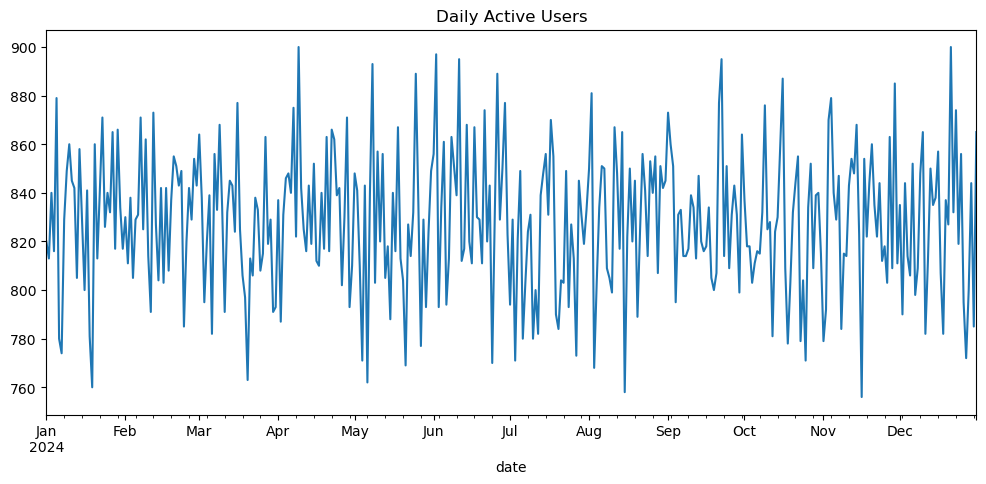

In [7]:
df = session_mart.copy()
df['event_datetime'] = pd.to_datetime(df['event_datetime'])
df['date'] = df['event_datetime'].dt.floor('D')

dau = df.groupby('date')['user_id'].nunique()

plt.figure(figsize=(12,5))
dau.plot()
plt.title("Daily Active Users")
plt.show()

Низкая ежедневная вовлечённость (stickiness ≈ 8%) объясняется спецификой продукта — e-commerce не является продуктом ежедневного использования.

В связи с этим, стратегически более целесообразно фокусироваться на росте MAU, а не DAU, поскольку ключевой драйвер выручки — расширение месячной активной аудитории, а не повышение ежедневной частоты использования.

### Renevue Анализ 

In [16]:
print(f"Процент сессий в которых был сделан заказ {session_conversion_rate(session_mart)*100:.2f}%")
print(f"APRAU: {APRAU(user_mart):.2f}")
print(f"AOV: {AOV(revenue_mart):.2f}")
print(f"Revenue per Session: {revenue_per_session(user_mart):.2f}")
print(f"Pareto (Top 30% revenue share): {PARETO(user_mart , top_share = .3):.3f}")

Процент сессий в которых был сделан заказ 7.98%
APRAU: 5939.44
AOV: 2838.49
Revenue per Session: 226.78
Pareto (Top 30% revenue share): 0.528


Несмотря на высокий средний чек (~2838), выручка на сессию остаётся низкой (~226). Это связано с тем, что лишь около 8% сессий конвертируются в покупку.

Таким образом, ключевым узким местом является конверсия, а не ценность заказа. Даже небольшое увеличение conversion rate способно значительно повысить монетизацию без изменения среднего чека.

Наблюдается выраженный эффект Парето: 30% пользователей генерируют ~52% выручки.


Это указывает на наличие сегмента высокоценностных пользователей, с которыми целесообразно работать отдельно (персонализированные предложения, программы лояльности, удержание).



### Retantion Analys

In [9]:
print(f"retention_7d : {retention(staging_events, days=7):.4f}")
print(f"retention_7d ± 1 : {retention(staging_events, days=7 , disp=1):.2f}")
print(f"retention_30d : {retention(staging_events, days=30):.4f}")
print(f"retention_30d ± 3 : {retention(staging_events, days=30 , disp = 3):.2f}")

retention_7d : 0.0659
retention_7d ± 1 : 0.19
retention_30d : 0.0696
retention_30d ± 3 : 0.39


In [10]:
ret_series = pd.Series({
    day: retention(staging_events, days=day)
    for day in range(1, 31)
})

max_day = ret_series.idxmax()

print(f"День с максимальным возратом : {max_day}, retention = {ret_series[max_day]*100:.2f}%")

День с максимальным возратом : 14, retention = 7.30%


In [11]:
print(f"Средний retention в день {ret_series.mean()*100:.2f}%")

Средний retention в день 6.87%


In [13]:
def plot_retention_curve(ret_series, title="Retention Curve"):
    
    fig, ax = plt.subplots(figsize=(10, 5))

    ax.plot(ret_series.index,
            ret_series.values,
            marker='o',
            linewidth=2)

    ax.set_title(title)
    ax.set_xlabel("Days Since First Visit")
    ax.set_ylabel("Retention Rate")

    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

    ax.grid(alpha=0.3)

    plt.show()

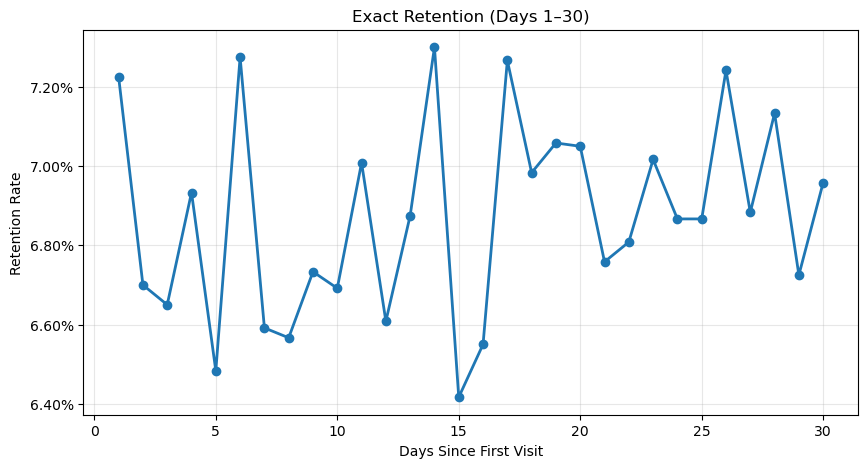

In [14]:
plot_retention_curve(ret_series, title="Exact Retention (Days 1–30)")


Retention имеет выраженный цикличный характер.


Exact-retention низкий, однако windowed retention значительно выше, что свидетельствует о том, что пользователи возвращаются не в строго определённый день, а в определённый временной интервал.


Это подтверждает гипотезу о транзакционной модели поведения и наличии потребительских циклов (примерно 14–30 дней).

np.float64(0.07978452609741507)